In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyxdf

In [8]:
# Adjust this only if needed
PROJECT_ROOT = Path.cwd().parent  # assumes notebook is inside meditation_group_synchrony/notebooks
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
LOGS_DIR = OUTPUTS_DIR / "logs"

for p in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

XDF_PATH = RAW_DIR / "session_01.xdf"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("XDF_PATH:", XDF_PATH)
print("Exists:", XDF_PATH.exists())

PROJECT_ROOT: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony
XDF_PATH: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/raw/session_01.xdf
Exists: True


In [9]:
EXPECTED_MARKERS = [
    "baseline",
    "start",
    "longer version meditation",
    "quiet session",
    "eyes open",
    "stop",
]

In [10]:
streams, header = pyxdf.load_xdf(str(XDF_PATH))

print(f"Loaded {len(streams)} streams")
print("Header keys:", list(header.keys()) if isinstance(header, dict) else type(header))

Loaded 22 streams
Header keys: ['info']


In [11]:
def safe_get(obj, *keys, default=None):
    """
    Safely walk nested dict/list structures.
    Example: safe_get(stream, 'info', 'name', 0)
    """
    cur = obj
    try:
        for k in keys:
            cur = cur[k]
        return cur
    except (KeyError, IndexError, TypeError):
        return default


def to_str(x):
    if x is None:
        return None
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")
    return str(x)


def clean_marker_text(x):
    if x is None:
        return None
    return str(x).strip().lower()


def estimate_sampling_rate(timestamps):
    timestamps = np.asarray(timestamps, dtype=float)
    if len(timestamps) < 2:
        return np.nan, np.nan, np.nan

    diffs = np.diff(timestamps)
    diffs = diffs[np.isfinite(diffs)]
    diffs = diffs[diffs > 0]

    if len(diffs) == 0:
        return np.nan, np.nan, np.nan

    mean_dt = np.mean(diffs)
    median_dt = np.median(diffs)
    fs_mean = 1.0 / mean_dt if mean_dt > 0 else np.nan
    fs_median = 1.0 / median_dt if median_dt > 0 else np.nan
    return fs_mean, fs_median, float(np.std(diffs))


def get_channel_labels(stream):
    """
    Try to extract channel labels from stream metadata.
    """
    channels = safe_get(stream, "info", "desc", 0, "channels", 0, "channel", default=[])
    labels = []
    if isinstance(channels, list):
        for ch in channels:
            label = safe_get(ch, "label", 0, default=None)
            labels.append(to_str(label))
    return labels


def summarize_stream(stream, idx):
    name = to_str(safe_get(stream, "info", "name", 0))
    stype = to_str(safe_get(stream, "info", "type", 0))
    uid = to_str(safe_get(stream, "info", "uid", 0))
    nominal_srate = safe_get(stream, "info", "nominal_srate", 0, default=None)
    channel_count = safe_get(stream, "info", "channel_count", 0, default=None)
    fmt = to_str(safe_get(stream, "info", "channel_format", 0))

    time_stamps = stream.get("time_stamps", [])
    time_series = stream.get("time_series", [])

    n_samples = len(time_stamps)
    start_time = float(time_stamps[0]) if n_samples > 0 else np.nan
    end_time = float(time_stamps[-1]) if n_samples > 0 else np.nan
    duration_sec = end_time - start_time if n_samples > 1 else np.nan

    fs_mean, fs_median, dt_std = estimate_sampling_rate(time_stamps)
    channel_labels = get_channel_labels(stream)

    return {
        "stream_index": idx,
        "name": name,
        "type": stype,
        "uid": uid,
        "nominal_srate": nominal_srate,
        "channel_count": channel_count,
        "channel_format": fmt,
        "n_samples": n_samples,
        "start_time": start_time,
        "end_time": end_time,
        "duration_sec": duration_sec,
        "estimated_fs_mean": fs_mean,
        "estimated_fs_median": fs_median,
        "timestamp_diff_std": dt_std,
        "channel_labels": channel_labels,
        "time_series_shape": np.asarray(time_series).shape,
    }

In [12]:
stream_rows = [summarize_stream(stream, idx) for idx, stream in enumerate(streams)]
stream_inventory = pd.DataFrame(stream_rows)

pd.set_option("display.max_colwidth", 200)
display(stream_inventory)

,stream_index,name,type,uid,nominal_srate,channel_count,channel_format,n_samples,start_time,end_time,duration_sec,estimated_fs_mean,estimated_fs_median,timestamp_diff_std,channel_labels,time_series_shape
0,0,EDA_EmotiBit_1,EDA,2bae793d-7a22-465f-b3d2-772b8061aca6,15.00000000000000,1,float32,16893,62847.602169,63971.433589,1123.831420,15.030724,15.030724,3.412692e-12,[],"(16893, 1)"
1,1,EDA_EmotiBit_3,EDA,530d8923-5d8f-4545-b4c6-d4f41a72f3c0,15.00000000000000,1,float32,16817,62847.669638,63971.352418,1123.682780,14.965078,14.965078,3.576275e-12,[],"(16817, 1)"
2,2,TEMP_EmotiBit_7,TEMP,06aeaee1-a0ef-4ca8-b298-1dcb66fd3c22,15.00000000000000,1,float32,16931,62847.490002,63971.553395,1124.063392,15.061428,15.061428,3.608469e-12,[],"(16931, 1)"
3,3,TEMP_EmotiBit_6,TEMP,ecf8afca-1616-4811-b8b8-6bb720aff682,15.00000000000000,1,float32,16810,62847.045899,63970.446607,1123.400708,14.962604,14.962604,3.561477e-12,[],"(16810, 1)"
4,4,PPG_EmotiBit_4,PPG,9d009d5b-6faa-4378-ab86-a62e0abe8901,100.0000000000000,3,float32,111383,62847.050907,63971.326119,1124.275212,99.070049,99.070049,3.083127e-12,[],"(111383, 3)"
5,5,EDA_EmotiBit_6,EDA,3731d757-13d0-477e-bc6e-ab9adc967580,15.00000000000000,1,float32,16810,62847.045844,63970.446545,1123.400702,14.962604,14.962604,3.304828e-12,[],"(16810, 1)"
6,6,TEMP_EmotiBit_1,TEMP,5e6b94eb-e4c2-4fe5-8244-36129e2edc50,15.00000000000000,1,float32,16893,62847.602219,63971.433633,1123.831415,15.030724,15.030724,3.348798e-12,[],"(16893, 1)"
7,7,MarkerStream,Markers,83561c2c-2b63-434a-b7e7-ab134d532c96,0.000000000000000,1,string,7,62858.874887,63951.232376,1092.357490,0.005493,0.006878,1.268523e+02,[],"(7, 1)"
8,8,EDA_EmotiBit_4,EDA,ce980e81-6957-418d-b038-99436382711b,15.00000000000000,1,float32,16809,62847.110193,63971.316390,1124.206197,14.950994,14.950994,8.364936e-13,[],"(16809, 1)"
9,9,PPG_EmotiBit_1,PPG,1e6a446d-7971-4560-8806-cc6f5d0b6ffb,100.0000000000000,3,float32,111837,62847.559699,63971.584144,1124.024445,99.496057,99.496057,3.551063e-12,[],"(111837, 3)"


In [13]:
display(stream_inventory[[
    "stream_index", "name", "type", "channel_count", "n_samples",
    "nominal_srate", "estimated_fs_median", "duration_sec", "channel_labels"
]].sort_values("stream_index"))

,stream_index,name,type,channel_count,n_samples,nominal_srate,estimated_fs_median,duration_sec,channel_labels
0,0,EDA_EmotiBit_1,EDA,1,16893,15.00000000000000,15.030724,1123.831420,[]
1,1,EDA_EmotiBit_3,EDA,1,16817,15.00000000000000,14.965078,1123.682780,[]
2,2,TEMP_EmotiBit_7,TEMP,1,16931,15.00000000000000,15.061428,1124.063392,[]
3,3,TEMP_EmotiBit_6,TEMP,1,16810,15.00000000000000,14.962604,1123.400708,[]
4,4,PPG_EmotiBit_4,PPG,3,111383,100.0000000000000,99.070049,1124.275212,[]
5,5,EDA_EmotiBit_6,EDA,1,16810,15.00000000000000,14.962604,1123.400702,[]
6,6,TEMP_EmotiBit_1,TEMP,1,16893,15.00000000000000,15.030724,1123.831415,[]
7,7,MarkerStream,Markers,1,7,0.000000000000000,0.006878,1092.357490,[]
8,8,EDA_EmotiBit_4,EDA,1,16809,15.00000000000000,14.950994,1124.206197,[]
9,9,PPG_EmotiBit_1,PPG,3,111837,100.0000000000000,99.496057,1124.024445,[]


In [14]:
marker_candidates = stream_inventory[
    stream_inventory["name"].str.contains("marker", case=False, na=False) |
    stream_inventory["type"].str.contains("marker", case=False, na=False)
].copy()

display(marker_candidates)

,stream_index,name,type,uid,nominal_srate,channel_count,channel_format,n_samples,start_time,end_time,duration_sec,estimated_fs_mean,estimated_fs_median,timestamp_diff_std,channel_labels,time_series_shape
7,7,MarkerStream,Markers,83561c2c-2b63-434a-b7e7-ab134d532c96,0.000000000000000,1,string,7,62858.874887,63951.232376,1092.35749,0.005493,0.006878,126.852319,[],"(7, 1)"


In [15]:
for _, row in stream_inventory.iterrows():
    print(
        f"[{row['stream_index']}] "
        f"name={row['name']} | type={row['type']} | "
        f"channels={row['channel_count']} | fs≈{row['estimated_fs_median']:.2f}"
    )

[0] name=EDA_EmotiBit_1 | type=EDA | channels=1 | fs≈15.03
[1] name=EDA_EmotiBit_3 | type=EDA | channels=1 | fs≈14.97
[2] name=TEMP_EmotiBit_7 | type=TEMP | channels=1 | fs≈15.06
[3] name=TEMP_EmotiBit_6 | type=TEMP | channels=1 | fs≈14.96
[4] name=PPG_EmotiBit_4 | type=PPG | channels=3 | fs≈99.07
[5] name=EDA_EmotiBit_6 | type=EDA | channels=1 | fs≈14.96
[6] name=TEMP_EmotiBit_1 | type=TEMP | channels=1 | fs≈15.03
[7] name=MarkerStream | type=Markers | channels=1 | fs≈0.01
[8] name=EDA_EmotiBit_4 | type=EDA | channels=1 | fs≈14.95
[9] name=PPG_EmotiBit_1 | type=PPG | channels=3 | fs≈99.50
[10] name=EDA_EmotiBit_2 | type=EDA | channels=1 | fs≈15.08
[11] name=EDA_EmotiBit_7 | type=EDA | channels=1 | fs≈15.06
[12] name=TEMP_EmotiBit_4 | type=TEMP | channels=1 | fs≈14.95
[13] name=EDA_EmotiBit_5 | type=EDA | channels=1 | fs≈14.95
[14] name=PPG_EmotiBit_7 | type=PPG | channels=3 | fs≈99.97
[15] name=PPG_EmotiBit_6 | type=PPG | channels=3 | fs≈99.12
[16] name=TEMP_EmotiBit_2 | type=TEMP | c

In [16]:
# Change this if needed after inspecting Cell 9/10
MARKER_STREAM_INDEX = int(marker_candidates.iloc[0]["stream_index"])
print("Using marker stream index:", MARKER_STREAM_INDEX)

Using marker stream index: 7


In [17]:
marker_stream = streams[MARKER_STREAM_INDEX]

marker_timestamps = marker_stream["time_stamps"]
marker_values_raw = marker_stream["time_series"]

marker_rows = []
for ts, val in zip(marker_timestamps, marker_values_raw):
    # val can be ['baseline'] or similar
    if isinstance(val, (list, np.ndarray)) and len(val) > 0:
        raw_text = to_str(val[0])
    else:
        raw_text = to_str(val)

    marker_rows.append({
        "timestamp": float(ts),
        "marker_raw": raw_text,
        "marker_clean": clean_marker_text(raw_text),
    })

marker_timeline = pd.DataFrame(marker_rows).sort_values("timestamp").reset_index(drop=True)
display(marker_timeline)

,timestamp,marker_raw,marker_clean
0,62858.874887,baseline,baseline
1,63006.653002,start,start
2,63102.985040,longer version meditation,longer version meditation
3,63564.003053,inbetween marker,inbetween marker
4,63707.023919,quiet session,quiet session
5,63856.455028,eyes open,eyes open
6,63951.232376,stop,stop


In [18]:
marker_timeline.to_csv(TABLES_DIR / "marker_timeline.csv", index=False)
print("Saved:", TABLES_DIR / "marker_timeline.csv")

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/marker_timeline.csv


In [19]:
marker_counts = (
    marker_timeline.groupby(["marker_clean"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["count", "marker_clean"], ascending=[False, True])
)

display(marker_counts)

,marker_clean,count
0,baseline,1
1,eyes open,1
2,inbetween marker,1
3,longer version meditation,1
4,quiet session,1
5,start,1
6,stop,1


In [20]:
observed = set(marker_timeline["marker_clean"].dropna().unique())
expected = set(EXPECTED_MARKERS)

print("Observed markers:", sorted(observed))
print("Expected markers:", sorted(expected))
print("Missing expected:", sorted(expected - observed))
print("Unexpected observed:", sorted(observed - expected))

Observed markers: ['baseline', 'eyes open', 'inbetween marker', 'longer version meditation', 'quiet session', 'start', 'stop']
Expected markers: ['baseline', 'eyes open', 'longer version meditation', 'quiet session', 'start', 'stop']
Missing expected: []
Unexpected observed: ['inbetween marker']


Build candidate segments

In [21]:
def first_timestamp_for_marker(df, marker_name):
    matches = df.loc[df["marker_clean"] == marker_name, "timestamp"]
    if len(matches) == 0:
        return np.nan
    return float(matches.iloc[0])


segment_defs = [
    ("pre_meditation", "baseline", "longer version meditation"),
    ("main_meditation", "longer version meditation", "eyes open"),
    ("recovery", "eyes open", "stop"),
]

segment_rows = []
for segment_name, start_marker, end_marker in segment_defs:
    start_ts = first_timestamp_for_marker(marker_timeline, start_marker)
    end_ts = first_timestamp_for_marker(marker_timeline, end_marker)

    segment_rows.append({
        "segment": segment_name,
        "start_marker": start_marker,
        "end_marker": end_marker,
        "start_time": start_ts,
        "end_time": end_ts,
        "duration_sec": end_ts - start_ts if pd.notna(start_ts) and pd.notna(end_ts) else np.nan,
        "valid": pd.notna(start_ts) and pd.notna(end_ts) and (end_ts > start_ts),
    })

candidate_segments = pd.DataFrame(segment_rows)
display(candidate_segments)

,segment,start_marker,end_marker,start_time,end_time,duration_sec,valid
0,pre_meditation,baseline,longer version meditation,62858.874887,63102.985040,244.110153,True
1,main_meditation,longer version meditation,eyes open,63102.985040,63856.455028,753.469988,True
2,recovery,eyes open,stop,63856.455028,63951.232376,94.777348,True


In [22]:
candidate_segments.to_csv(TABLES_DIR / "candidate_segments.csv", index=False)
print("Saved:", TABLES_DIR / "candidate_segments.csv")

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/candidate_segments.csv


In [23]:
ppg_candidates = stream_inventory[
    stream_inventory["name"].str.contains("ppg", case=False, na=False) |
    stream_inventory["type"].str.contains("ppg", case=False, na=False)
].copy()

display(ppg_candidates[[
    "stream_index", "name", "type", "channel_count", "n_samples",
    "nominal_srate", "estimated_fs_median", "channel_labels", "time_series_shape"
]].sort_values("stream_index"))

,stream_index,name,type,channel_count,n_samples,nominal_srate,estimated_fs_median,channel_labels,time_series_shape
4,4,PPG_EmotiBit_4,PPG,3,111383,100.0000000000000,99.070049,[],"(111383, 3)"
9,9,PPG_EmotiBit_1,PPG,3,111837,100.0000000000000,99.496057,[],"(111837, 3)"
14,14,PPG_EmotiBit_7,PPG,3,112387,100.0000000000000,99.972308,[],"(112387, 3)"
15,15,PPG_EmotiBit_6,PPG,3,111362,100.0000000000000,99.118170,[],"(111362, 3)"
17,17,PPG_EmotiBit_5,PPG,3,111277,100.0000000000000,99.011845,[],"(111277, 3)"
19,19,PPG_EmotiBit_3,PPG,3,111168,100.0000000000000,98.920147,[],"(111168, 3)"
20,20,PPG_EmotiBit_2,PPG,3,112432,100.0000000000000,100.020871,[],"(112432, 3)"


In [24]:
ppg_stream_summary = ppg_candidates.copy()

# Add simple quality indicators
ppg_stream_summary["duration_min"] = ppg_stream_summary["duration_sec"] / 60.0
ppg_stream_summary["fs_close_to_100hz"] = ppg_stream_summary["estimated_fs_median"].between(95, 105, inclusive="both")
ppg_stream_summary["has_3plus_channels"] = pd.to_numeric(ppg_stream_summary["channel_count"], errors="coerce") >= 3

display(ppg_stream_summary[[
    "stream_index", "name", "type", "channel_count", "n_samples",
    "duration_min", "nominal_srate", "estimated_fs_median",
    "fs_close_to_100hz", "has_3plus_channels", "channel_labels"
]].sort_values("stream_index"))

,stream_index,name,type,channel_count,n_samples,duration_min,nominal_srate,estimated_fs_median,fs_close_to_100hz,has_3plus_channels,channel_labels
4,4,PPG_EmotiBit_4,PPG,3,111383,18.737920,100.0000000000000,99.070049,True,True,[]
9,9,PPG_EmotiBit_1,PPG,3,111837,18.733741,100.0000000000000,99.496057,True,True,[]
14,14,PPG_EmotiBit_7,PPG,3,112387,18.736188,100.0000000000000,99.972308,True,True,[]
15,15,PPG_EmotiBit_6,PPG,3,111362,18.725292,100.0000000000000,99.118170,True,True,[]
17,17,PPG_EmotiBit_5,PPG,3,111277,18.731092,100.0000000000000,99.011845,True,True,[]
19,19,PPG_EmotiBit_3,PPG,3,111168,18.730091,100.0000000000000,98.920147,True,True,[]
20,20,PPG_EmotiBit_2,PPG,3,112432,18.734590,100.0000000000000,100.020871,True,True,[]


In [25]:
ppg_stream_summary.to_csv(TABLES_DIR / "ppg_stream_summary.csv", index=False)
print("Saved:", TABLES_DIR / "ppg_stream_summary.csv")

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_stream_summary.csv


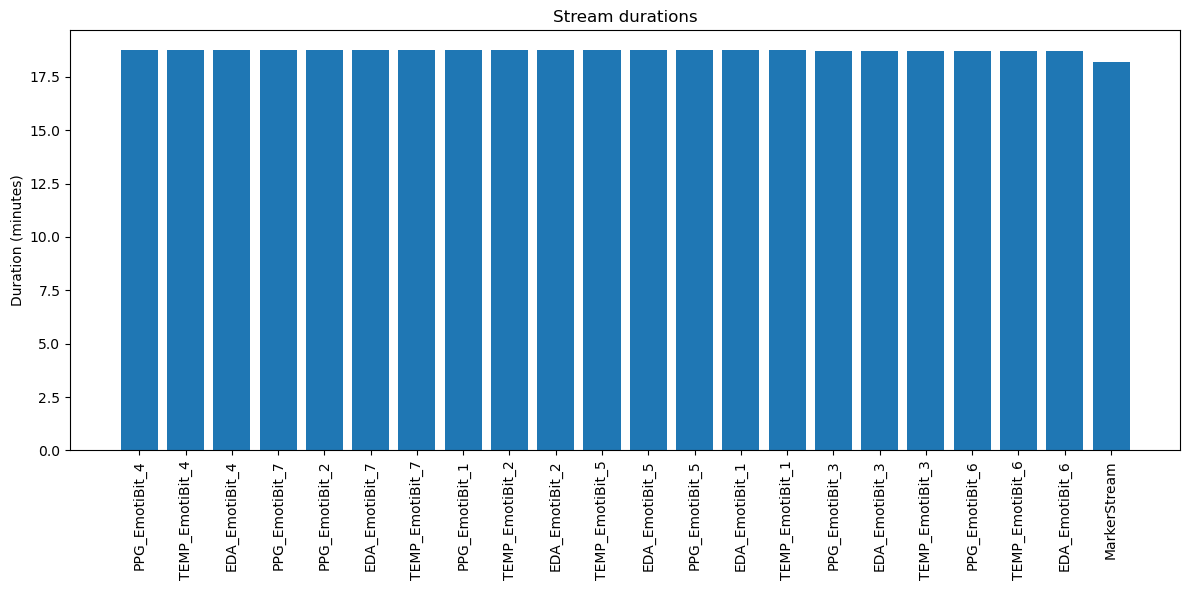

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/stream_durations.png


In [26]:
plot_df = stream_inventory.copy().sort_values("duration_sec", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(plot_df)), plot_df["duration_sec"] / 60.0)
plt.xticks(range(len(plot_df)), plot_df["name"].fillna("UNKNOWN"), rotation=90)
plt.ylabel("Duration (minutes)")
plt.title("Stream durations")
plt.tight_layout()

out_path = FIGURES_DIR / "stream_durations.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

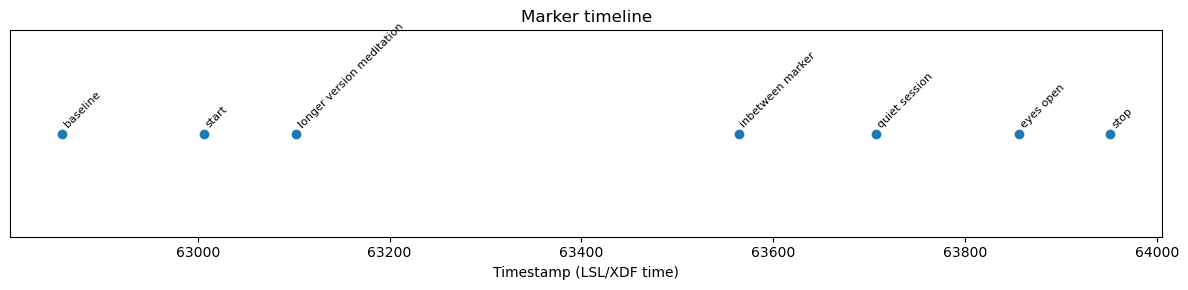

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/marker_timeline.png


In [27]:
plt.figure(figsize=(12, 3))

y = np.ones(len(marker_timeline))
plt.scatter(marker_timeline["timestamp"], y)

for _, row in marker_timeline.iterrows():
    plt.text(row["timestamp"], 1.002, row["marker_clean"], rotation=45, ha="left", va="bottom", fontsize=8)

plt.yticks([])
plt.xlabel("Timestamp (LSL/XDF time)")
plt.title("Marker timeline")
plt.tight_layout()

out_path = FIGURES_DIR / "marker_timeline.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [29]:
quality_rows = []

for idx in ppg_candidates["stream_index"].tolist():
    stream = streams[idx]
    ts = np.asarray(stream["time_stamps"], dtype=float)

    if len(ts) < 2:
        quality_rows.append({
            "stream_index": idx,
            "name": to_str(safe_get(stream, "info", "name", 0)),
            "n_timestamps": len(ts),
            "missing_or_short": True,
            "median_dt": np.nan,
            "max_dt": np.nan,
            "n_large_gaps": np.nan,
        })
        continue

    dts = np.diff(ts)
    median_dt = np.median(dts)
    max_dt = np.max(dts)

    # "large gap" threshold = 5x median interval
    threshold = 5 * median_dt if median_dt > 0 else np.inf
    n_large_gaps = int(np.sum(dts > threshold))

    quality_rows.append({
        "stream_index": idx,
        "name": to_str(safe_get(stream, "info", "name", 0)),
        "n_timestamps": len(ts),
        "missing_or_short": False,
        "median_dt": median_dt,
        "max_dt": max_dt,
        "n_large_gaps": n_large_gaps,
    })

ppg_quality = pd.DataFrame(quality_rows)
display(ppg_quality.sort_values(["n_large_gaps", "max_dt"], ascending=[False, False]))

,stream_index,name,n_timestamps,missing_or_short,median_dt,max_dt,n_large_gaps
5,19,PPG_EmotiBit_3,111168,False,0.010109,0.010109,0
4,17,PPG_EmotiBit_5,111277,False,0.010100,0.010100,0
0,4,PPG_EmotiBit_4,111383,False,0.010094,0.010094,0
3,15,PPG_EmotiBit_6,111362,False,0.010089,0.010089,0
1,9,PPG_EmotiBit_1,111837,False,0.010051,0.010051,0
2,14,PPG_EmotiBit_7,112387,False,0.010003,0.010003,0
6,20,PPG_EmotiBit_2,112432,False,0.009998,0.009998,0


In [30]:
ppg_quality.to_csv(TABLES_DIR / "ppg_timestamp_quality.csv", index=False)
print("Saved:", TABLES_DIR / "ppg_timestamp_quality.csv")

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_timestamp_quality.csv


In [31]:
print("=== DATA AUDIT SUMMARY ===")
print(f"Total streams: {len(stream_inventory)}")
print(f"Likely PPG streams: {len(ppg_candidates)}")
print(f"Likely marker streams: {len(marker_candidates)}")

print("\nObserved markers:")
for m in sorted(observed):
    print("-", m)

print("\nCandidate segments:")
display(candidate_segments)

print("\nNext questions after this notebook:")
print("1. Are the detected PPG streams exactly the 7 EmotiBits?")
print("2. Which PPG channel should we use per participant?")
print("3. Are there any participants with poor signal or large timestamp gaps?")
print("4. Are the marker times and segment definitions valid?")

=== DATA AUDIT SUMMARY ===
Total streams: 22
Likely PPG streams: 7
Likely marker streams: 1

Observed markers:
- baseline
- eyes open
- inbetween marker
- longer version meditation
- quiet session
- start
- stop

Candidate segments:


,segment,start_marker,end_marker,start_time,end_time,duration_sec,valid
0,pre_meditation,baseline,longer version meditation,62858.874887,63102.985040,244.110153,True
1,main_meditation,longer version meditation,eyes open,63102.985040,63856.455028,753.469988,True
2,recovery,eyes open,stop,63856.455028,63951.232376,94.777348,True



Next questions after this notebook:
1. Are the detected PPG streams exactly the 7 EmotiBits?
2. Which PPG channel should we use per participant?
3. Are there any participants with poor signal or large timestamp gaps?
4. Are the marker times and segment definitions valid?
